In [ ]:
---
title: lab_test
description: Lab Model API
show-code: false
---
import mercury as mr
import base64

# 1. نستقبل الصورة كنص بدل ما نستخدم mr.File اللي بيعمل مشاكل
file_b64 = mr.Text(label="file_b64", value="")
file_name = mr.Text(label="file_name", value="uploaded_file.png")

if file_b64.value:
    # 2. بنشيل الزيادات من النص ونحوله لبيانات حقيقية
    b64_string = file_b64.value.split(',')[1] if ',' in file_b64.value else file_b64.value
    
    # 3. بنحفظ الملف على الجهاز باسمه الأصلي
    save_path = file_name.value
    with open(save_path, "wb") as f:
        f.write(base64.b64decode(b64_string))
        
    # ⚠️ الآن: الملف موجود على الجهاز باسم save_path
    # تقدر تباصي الـ save_path للموديل بتاعك عشان يقراه ويطلع النتيجة!
    # مثال: results = model.predict(save_path)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Running on: cuda



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\pc\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\pc\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\pc\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\pc\anaconda3\Lib\site-packages\tornado

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [2]:
!pip install ultralytics -q
!pip install roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 67.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [3]:
import os
import glob
import random
import xml.etree.ElementTree as ET
import shutil
from pathlib import Path
import zipfile
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import yaml
from collections import Counter

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
import os
print("Current working directory:", os.getcwd())
print("Files in input directory:", os.listdir('/kaggle/input') if os.path.exists('/kaggle/input') else "No input directory")

# The dataset should be at /kaggle/input/dental-periapical-x-rayss
dataset_path = '/kaggle/input/datasets/nadaaglan/dental-periapical-x-rayss'
if os.path.exists(dataset_path):
    print(f"Dataset found at {dataset_path}")
    print("Contents:", os.listdir(dataset_path))
else:
    print("Please ensure the dataset is added to this notebook")

Current working directory: /kaggle/working
Files in input directory: ['datasets']
Dataset found at /kaggle/input/datasets/nadaaglan/dental-periapical-x-rayss
Contents: ['dental']


In [5]:
from pathlib import Path

data_root = Path('/kaggle/working/dental_data')
data_root.mkdir(exist_ok=True)

# Find and extract the dataset
zip_files = list(Path('/kaggle/input/datasets/nadaaglan/dental-periapical-x-rayss').glob('*.zip'))
if zip_files:
    print(f"Extracting {zip_files[0]}...")
    with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
        zip_ref.extractall(data_root)
    print("Extraction complete!")

# Find images and annotations directories
images_dir = Path("/kaggle/input/datasets/nadaaglan/dental-periapical-x-rayss/dental/images")
annotations_dir = Path("/kaggle/input/datasets/nadaaglan/dental-periapical-x-rayss/dental/annotation")

for root, dirs, files in os.walk(data_root):
    if 'images' in dirs and 'annotation' in dirs:
        images_dir = Path(root) / 'images'
        annotations_dir = Path(root) / 'annotation'
        break
    elif 'train' in dirs:
        # Alternative structure
        if (Path(root) / 'train' / 'images').exists():
            images_dir = Path(root) / 'train' / 'images'
            annotations_dir = Path(root) / 'train' / 'annotation'

if images_dir and annotations_dir:
    print(f"Images directory: {images_dir}")
    print(f"Annotations directory: {annotations_dir}")
    print(f"Number of images: {len(list(images_dir.glob('*')))}")
    print(f"Number of annotations: {len(list(annotations_dir.glob('*.xml')))}")
else:
    print("Please manually set the paths")
    # Fallback: try to find manually
    for path in data_root.rglob('*'):
        if path.is_dir():
            if 'image' in str(path).lower() and len(list(path.glob('*.jpg'))) > 0:
                images_dir = path
            if 'annotation' in str(path).lower() and len(list(path.glob('*.xml'))) > 0:
                annotations_dir = path
    
    if images_dir and annotations_dir:
        print(f"Found - Images: {images_dir}, Annotations: {annotations_dir}")

Images directory: /kaggle/input/datasets/nadaaglan/dental-periapical-x-rayss/dental/images
Annotations directory: /kaggle/input/datasets/nadaaglan/dental-periapical-x-rayss/dental/annotation
Number of images: 1899
Number of annotations: 1899


In [6]:
def get_all_classes(annotations_dir):
    """Extract all unique class names from XML files"""
    classes = set()
    for xml_file in annotations_dir.glob('*.xml'):
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            for obj in root.findall('object'):
                name = obj.find('name').text
                classes.add(name)
        except:
            continue
    return sorted(list(classes))

all_classes = get_all_classes(annotations_dir)
print(f"All classes found in dataset: {all_classes}")

All classes found in dataset: ['Badly Decayed', 'Caries', 'Crown', 'Normal', 'RCT', 'Restoration']


In [7]:
class_to_id = {cls: i for i, cls in enumerate(all_classes)}
id_to_class = {i: cls for cls, i in class_to_id.items()}
print(f"Class mapping: {class_to_id}")

Class mapping: {'Badly Decayed': 0, 'Caries': 1, 'Crown': 2, 'Normal': 3, 'RCT': 4, 'Restoration': 5}


In [8]:
def validate_xml(xml_path, images_dir):
    """Validate XML file and check corresponding image"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        objects = root.findall('object')
        
        if len(objects) == 0:
            return False, "No objects"
        
        # Check image exists
        img_name = root.find('filename').text
        img_path = images_dir / img_name
        
        if not img_path.exists():
            # Try with different extensions
            for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
                alt_path = images_dir / (Path(img_name).stem + ext)
                if alt_path.exists():
                    img_path = alt_path
                    break
            else:
                return False, f"Image missing: {img_name}"
        
        # Validate bounding boxes
        for obj in objects:
            bndbox = obj.find('bndbox')
            if bndbox is None:
                return False, "Missing bndbox"
            
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            
            if xmin >= xmax or ymin >= ymax:
                return False, "Invalid bbox dimensions"
            
            if xmin < 0 or ymin < 0:
                return False, "Negative bbox coordinates"
        
        return True, img_path
    except Exception as e:
        return False, str(e)

In [9]:
print("Validating dataset...")
valid_pairs = []
invalid_count = 0
class_counts = Counter()

for xml_file in tqdm(list(annotations_dir.glob('*.xml'))):
    valid, info = validate_xml(xml_file, images_dir)
    if valid:
        # Count classes in this file
        tree = ET.parse(xml_file)
        root = tree.getroot()
        for obj in root.findall('object'):
            class_counts[obj.find('name').text] += 1
        valid_pairs.append((xml_file, info))
    else:
        invalid_count += 1

print(f"\n✅ Valid annotations: {len(valid_pairs)}")
print(f"❌ Invalid annotations: {invalid_count}")
print(f"\nClass distribution:")
for cls, count in class_counts.most_common():
    print(f"  {cls}: {count} instances")

Validating dataset...


100%|██████████| 1899/1899 [00:03<00:00, 552.72it/s]


✅ Valid annotations: 1899
❌ Invalid annotations: 0

Class distribution:
  Badly Decayed: 416 instances
  Normal: 407 instances
  RCT: 400 instances
  Caries: 400 instances
  Crown: 366 instances
  Restoration: 339 instances


In [10]:
def analyze_annotations(xml_files, images_dir):
    """Extract bbox statistics"""
    bbox_widths = []
    bbox_heights = []
    bbox_areas = []
    image_sizes = []
    
    for xml_file in tqdm(xml_files, desc="Analyzing annotations"):
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            
            # Get image dimensions
            img_name = root.find('filename').text
            img_path = images_dir / img_name
            if not img_path.exists():
                for ext in ['.jpg', '.jpeg', '.png']:
                    alt_path = images_dir / (Path(img_name).stem + ext)
                    if alt_path.exists():
                        img_path = alt_path
                        break
            
            if img_path.exists():
                img = cv2.imread(str(img_path))
                if img is not None:
                    h, w = img.shape[:2]
                    image_sizes.append((w, h))
                    
                    # Process objects
                    for obj in root.findall('object'):
                        bndbox = obj.find('bndbox')
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        
                        bbox_w = (xmax - xmin) / w
                        bbox_h = (ymax - ymin) / h
                        
                        bbox_widths.append(bbox_w)
                        bbox_heights.append(bbox_h)
                        bbox_areas.append(bbox_w * bbox_h)
        except:
            continue
    
    return bbox_widths, bbox_heights, bbox_areas, image_sizes

bbox_widths, bbox_heights, bbox_areas, image_sizes = analyze_annotations([p[0] for p in valid_pairs], images_dir)

Analyzing annotations: 100%|██████████| 1899/1899 [00:16<00:00, 113.94it/s]


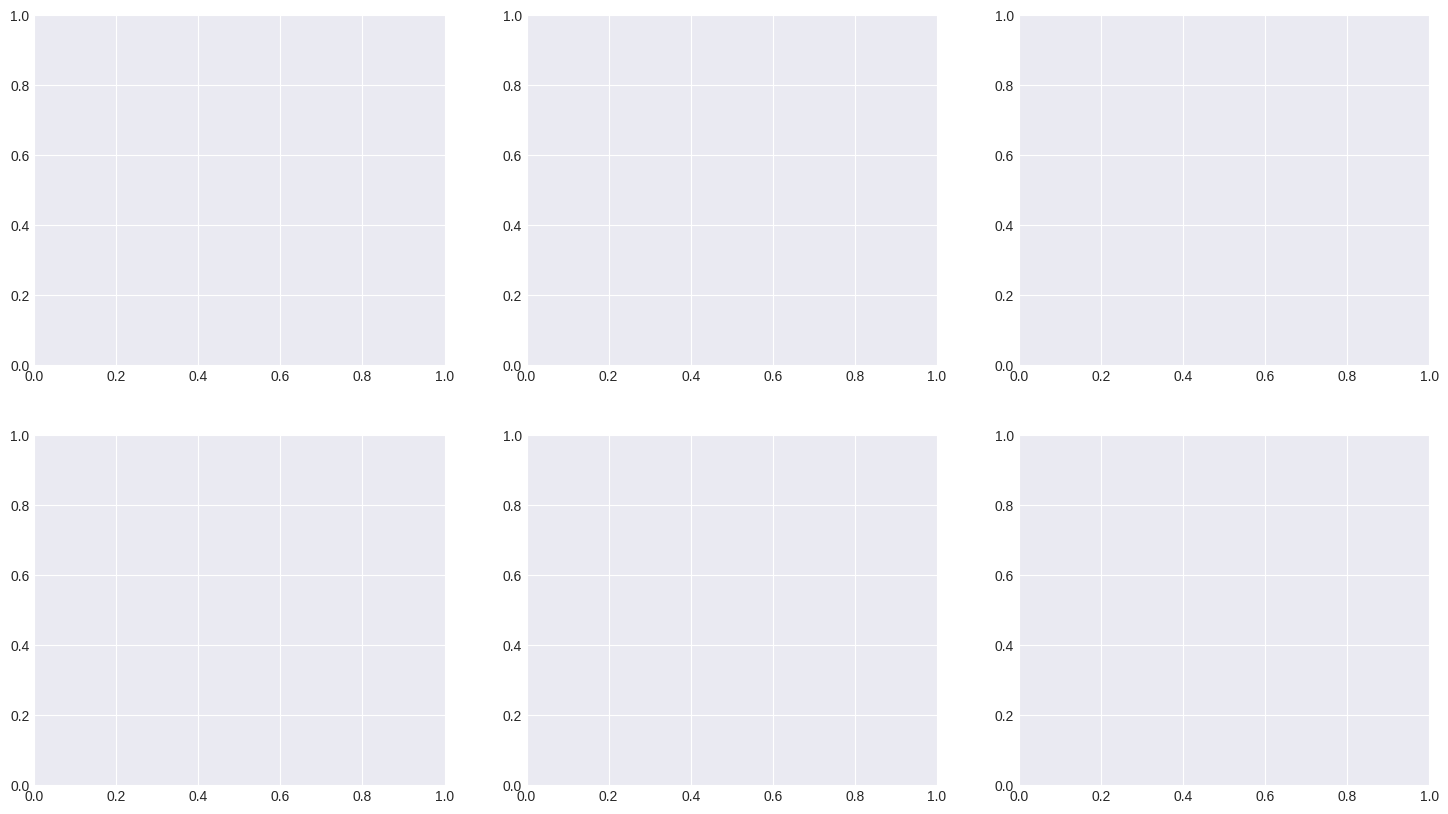

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

In [12]:
# 1. BBox width distribution
axes[0,0].hist(bbox_widths, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_xlabel('Normalized Width')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Bounding Box Width Distribution')
axes[0,0].axvline(np.mean(bbox_widths), color='red', linestyle='--', label=f'Mean: {np.mean(bbox_widths):.3f}')
axes[0,0].legend()

In [13]:
# 2. BBox height distribution
axes[0,1].hist(bbox_heights, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0,1].set_xlabel('Normalized Height')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Bounding Box Height Distribution')
axes[0,1].axvline(np.mean(bbox_heights), color='red', linestyle='--', label=f'Mean: {np.mean(bbox_heights):.3f}')
axes[0,1].legend()

In [14]:
# 3. BBox area distribution
axes[0,2].hist(bbox_areas, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0,2].set_xlabel('Normalized Area')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title('Bounding Box Area Distribution')
axes[0,2].axvline(np.mean(bbox_areas), color='red', linestyle='--', label=f'Mean: {np.mean(bbox_areas):.3f}')
axes[0,2].legend()

In [15]:
# 4. Class distribution bar chart
classes = list(class_counts.keys())
counts = list(class_counts.values())
bars = axes[1,0].bar(classes, counts, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Class')
axes[1,0].set_ylabel('Number of Instances')
axes[1,0].set_title('Class Distribution')
axes[1,0].tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar, count in zip(bars, counts):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                   str(count), ha='center', va='bottom')

In [16]:
# 5. Image dimensions scatter plot
if image_sizes:
    widths_img, heights_img = zip(*image_sizes)
    axes[1,1].scatter(widths_img, heights_img, alpha=0.5, s=10)
    axes[1,1].set_xlabel('Image Width (pixels)')
    axes[1,1].set_ylabel('Image Height (pixels)')
    axes[1,1].set_title('Image Dimensions Distribution')
    axes[1,1].grid(True, alpha=0.3)

In [17]:
# 6. Boxplot of bbox sizes by class (if multiple classes)
if len(classes) > 1:
    class_areas = {cls: [] for cls in classes}
    for xml_file, _ in valid_pairs[:500]:  # Sample for speed
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            img_name = root.find('filename').text
            img_path = images_dir / img_name
            if img_path.exists():
                img = cv2.imread(str(img_path))
                if img is not None:
                    h, w = img.shape[:2]
                    for obj in root.findall('object'):
                        cls = obj.find('name').text
                        bndbox = obj.find('bndbox')
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        area = ((xmax - xmin) / w) * ((ymax - ymin) / h)
                        class_areas[cls].append(area)
        except:
            continue
    
    data_to_plot = [class_areas[cls] for cls in classes if class_areas[cls]]
    bp = axes[1,2].boxplot(data_to_plot, labels=[cls for cls in classes if class_areas[cls]], 
                           patch_artist=True)
    axes[1,2].set_xlabel('Class')
    axes[1,2].set_ylabel('Normalized Area')
    axes[1,2].set_title('BBox Area by Class')
    axes[1,2].tick_params(axis='x', rotation=45)
else:
    axes[1,2].text(0.5, 0.5, 'Single class only\n(no comparison)', 
                   ha='center', va='center', transform=axes[1,2].transAxes)
    axes[1,2].set_title('Class Comparison')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 EDA Summary:")
print(f"  Total images: {len(valid_pairs)}")
print(f"  Total annotations: {sum(class_counts.values())}")
print(f"  Average bbox width: {np.mean(bbox_widths):.3f}")
print(f"  Average bbox height: {np.mean(bbox_heights):.3f}")
print(f"  Average bbox area: {np.mean(bbox_areas):.3f}")

<Figure size 640x480 with 0 Axes>


📊 EDA Summary:
  Total images: 1899
  Total annotations: 2328
  Average bbox width: 0.328
  Average bbox height: 0.336
  Average bbox area: 0.124


In [18]:
def convert_xml_to_yolo(xml_path, img_width, img_height, class_to_id):
    """Convert XML annotation to YOLO format"""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = root.findall('object')
    
    yolo_annotations = []
    for obj in objects:
        name = obj.find('name').text
        if name not in class_to_id:
            continue
        
        class_id = class_to_id[name]
        bndbox = obj.find('bndbox')
        
        xmin = float(bndbox.find('xmin').text)
        ymin = float(bndbox.find('ymin').text)
        xmax = float(bndbox.find('xmax').text)
        ymax = float(bndbox.find('ymax').text)
        
        # Convert to YOLO format (center x, center y, width, height)
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height
        
        # Clamp to [0, 1]
        x_center = np.clip(x_center, 0, 1)
        y_center = np.clip(y_center, 0, 1)
        width = np.clip(width, 0, 1)
        height = np.clip(height, 0, 1)
        
        yolo_annotations.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")
    
    return yolo_annotations

In [19]:
yolo_dataset_dir = Path('/kaggle/working/yolo_dataset')
for split in ['train', 'val']:
    (yolo_dataset_dir / split / 'images').mkdir(parents=True, exist_ok=True)
    (yolo_dataset_dir / split / 'labels').mkdir(parents=True, exist_ok=True)

# Split data
train_pairs, val_pairs = train_test_split(valid_pairs, test_size=0.2, random_state=42)
print(f"Training set: {len(train_pairs)} images")
print(f"Validation set: {len(val_pairs)} images")

# %%
# Process training set
print("Converting training annotations...")
for xml_file, img_path in tqdm(train_pairs):
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    
    h, w = img.shape[:2]
    
    # Convert annotations
    yolo_anns = convert_xml_to_yolo(xml_file, w, h, class_to_id)
    
    # Copy image to destination
    img_name = img_path.name
    dst_img_path = yolo_dataset_dir / 'train' / 'images' / img_name
    shutil.copy(img_path, dst_img_path)
    
    # Save YOLO annotations
    label_name = Path(img_name).stem + '.txt'
    label_path = yolo_dataset_dir / 'train' / 'labels' / label_name
    with open(label_path, 'w') as f:
        f.write('\n'.join(yolo_anns))

# Process validation set
print("Converting validation annotations...")
for xml_file, img_path in tqdm(val_pairs):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    
    h, w = img.shape[:2]
    yolo_anns = convert_xml_to_yolo(xml_file, w, h, class_to_id)
    
    img_name = img_path.name
    dst_img_path = yolo_dataset_dir / 'val' / 'images' / img_name
    shutil.copy(img_path, dst_img_path)
    
    label_name = Path(img_name).stem + '.txt'
    label_path = yolo_dataset_dir / 'val' / 'labels' / label_name
    with open(label_path, 'w') as f:
        f.write('\n'.join(yolo_anns))

print("✅ Dataset conversion complete!")

Training set: 1519 images
Validation set: 380 images
Converting training annotations...


100%|██████████| 1519/1519 [00:06<00:00, 229.80it/s]


Converting validation annotations...


100%|██████████| 380/380 [00:01<00:00, 208.12it/s]

✅ Dataset conversion complete!


In [20]:
data_config = {
    'path': str(yolo_dataset_dir.absolute()),
    'train': 'train/images',
    'val': 'val/images',
    'nc': len(class_to_id),
    'names': all_classes
}

with open(yolo_dataset_dir / 'data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("Data configuration saved:")
print(yaml.dump(data_config, default_flow_style=False))

Data configuration saved:
names:
- Badly Decayed
- Caries
- Crown
- Normal
- RCT
- Restoration
nc: 6
path: /kaggle/working/yolo_dataset
train: train/images
val: val/images



In [21]:
model = YOLO('yolov8n.pt')  # Using nano model for speed, use 'yolov8s.pt' for better accuracy

# Training parameters
results = model.train(
    data=str(yolo_dataset_dir / 'data.yaml'),
    epochs=100,  # Number of epochs
    imgsz=640,   # Image size
    batch=16,    # Batch size (reduce if out of memory)
    device='cuda',  # Use GPU
    workers=8,
    patience=15,  # Early stopping patience
    save=True,
    save_period=10,  # Save checkpoint every 10 epochs
    project='dental_model',
    name='yolov8n_periapical',
    exist_ok=True,
    pretrained=True,
    optimizer='AdamW',
    lr0=0.001,  # Initial learning rate
    weight_decay=0.0005,
    momentum=0.937,
    warmup_epochs=3,
    warmup_momentum=0.8,
    box=7.5,  # Box loss gain
    cls=0.5,  # Class loss gain
    dfl=1.5,  # DFL loss gain
    hsv_h=0.015,  # HSV-Hue augmentation
    hsv_s=0.7,    # HSV-Saturation augmentation
    hsv_v=0.4,    # HSV-Value augmentation
    degrees=0.0,  # Rotation augmentation
    translate=0.1,  # Translation augmentation
    scale=0.5,     # Scaling augmentation
    shear=0.0,     # Shear augmentation
    perspective=0.0,  # Perspective augmentation
    flipud=0.0,    # Flip up-down
    fliplr=0.5,    # Flip left-right
    mosaic=1.0,    # Mosaic augmentation
    mixup=0.0,     # Mixup augmentation
    copy_paste=0.0  # Copy-paste augmentation
)

print("✅ Training completed!")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_periapical, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pati

In [22]:
best_model_path = '/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.pt'
model = YOLO(best_model_path)

In [23]:
metrics = model.val(data=str(yolo_dataset_dir / 'data.yaml'))

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1077.0±340.6 MB/s, size: 39.7 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 380 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 380/380 144.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 6.3it/s 3.8s
                   all        380        469      0.692      0.708       0.73      0.562
         Badly Decayed         67         85      0.705      0.741      0.745      0.473
                Caries         68         87      0.513      0.368      0.378      0.187
                 Crown         48         58      0.805          1      0.967      0.893
                Normal         72         88       0.69      0.734      0.719      0.609
                   RCT         60     

In [24]:
print("\n" + "="*60)
print("📊 MODEL EVALUATION METRICS")
print("="*60)
print(f"mAP50 (IoU=0.5): {metrics.box.map50:.4f}")
print(f"mAP50-95 (IoU=0.5:0.95): {metrics.box.map:.4f}")
print(f"Precision (macro): {metrics.box.mp:.4f}")
print(f"Recall (macro): {metrics.box.mr:.4f}")
print(f"mAP per class: {metrics.box.ap_class_index}")
print("="*60)


📊 MODEL EVALUATION METRICS
mAP50 (IoU=0.5): 0.7297
mAP50-95 (IoU=0.5:0.95): 0.5619
Precision (macro): 0.6918
Recall (macro): 0.7082
mAP per class: [0 1 2 3 4 5]


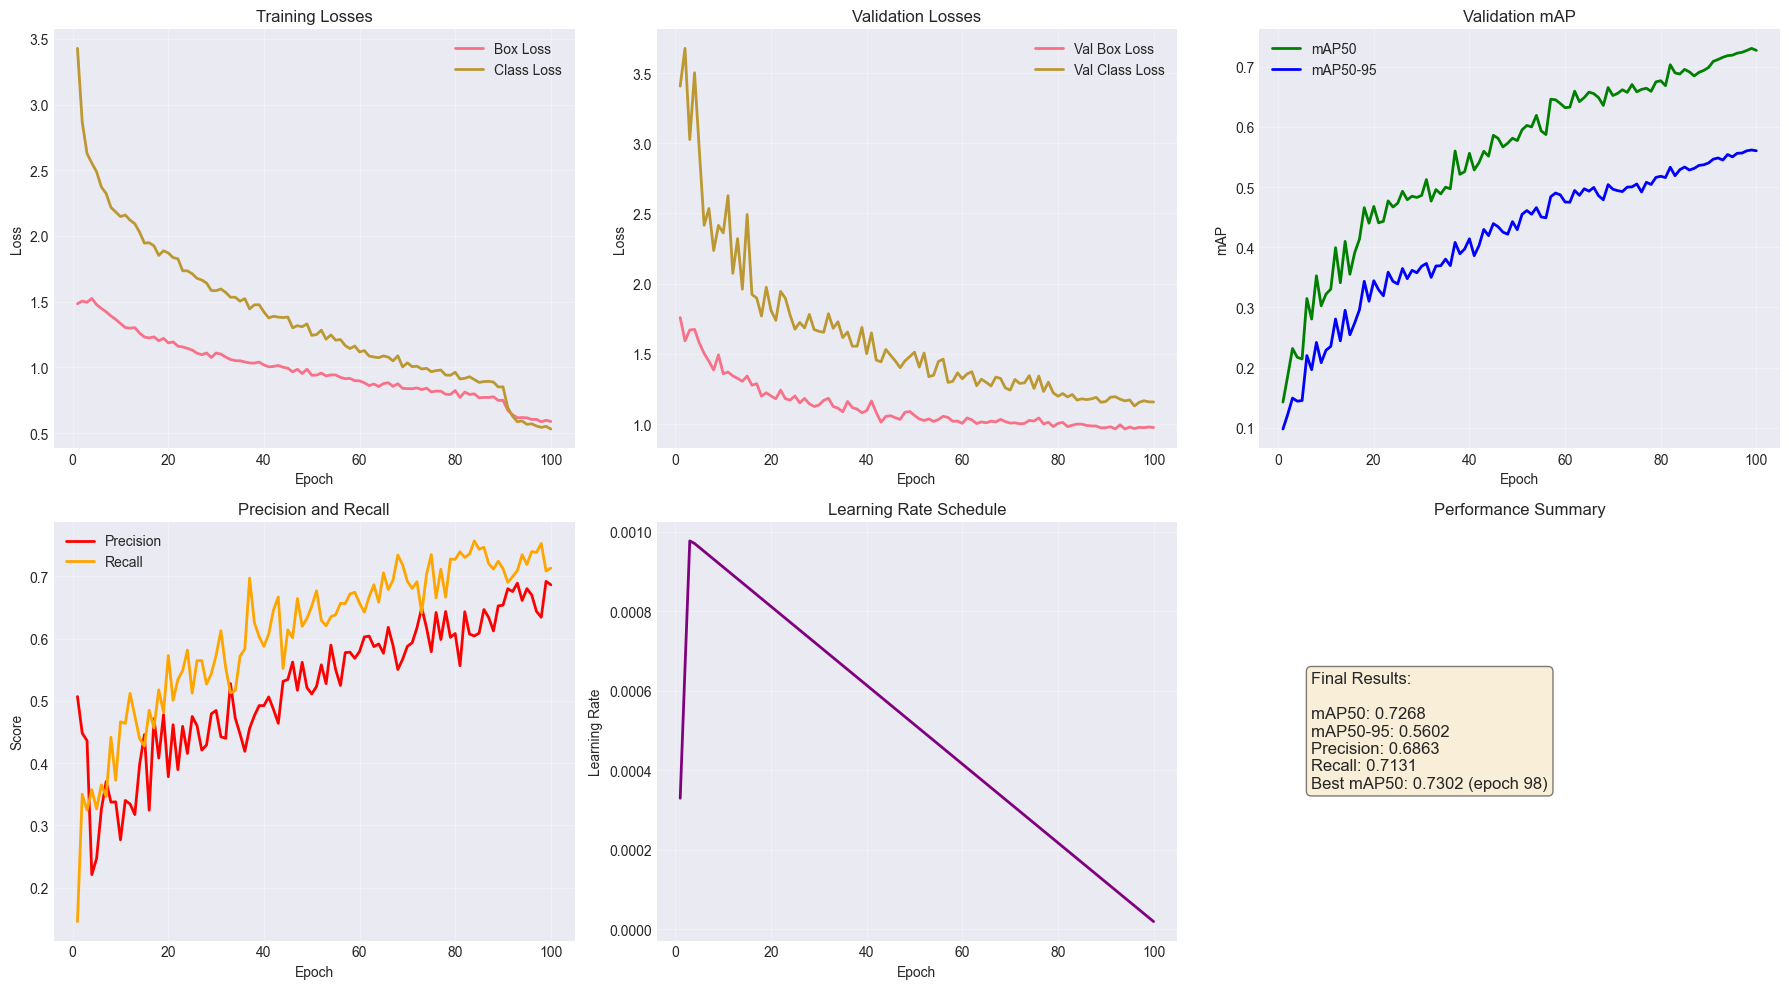

In [25]:
# Plot training results
def plot_training_results(results_path='/kaggle/working/runs/detect/dental_model/yolov8n_periapical'):
    """Plot training metrics from results.csv"""
    csv_path = Path(results_path) / 'results.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        
        # Loss plots
        axes[0,0].plot(df['epoch'], df['train/box_loss'], label='Box Loss', linewidth=2)
        axes[0,0].plot(df['epoch'], df['train/cls_loss'], label='Class Loss', linewidth=2)
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Loss')
        axes[0,0].set_title('Training Losses')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Validation loss
        axes[0,1].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', linewidth=2)
        axes[0,1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', linewidth=2)
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('Loss')
        axes[0,1].set_title('Validation Losses')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
        
        # mAP metrics
        axes[0,2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', linewidth=2, color='green')
        axes[0,2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', linewidth=2, color='blue')
        axes[0,2].set_xlabel('Epoch')
        axes[0,2].set_ylabel('mAP')
        axes[0,2].set_title('Validation mAP')
        axes[0,2].legend()
        axes[0,2].grid(True, alpha=0.3)
        
        # Precision-Recall
        axes[1,0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2, color='red')
        axes[1,0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2, color='orange')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('Score')
        axes[1,0].set_title('Precision and Recall')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Learning rate
        if 'lr/pg0' in df.columns:
            axes[1,1].plot(df['epoch'], df['lr/pg0'], linewidth=2, color='purple')
            axes[1,1].set_xlabel('Epoch')
            axes[1,1].set_ylabel('Learning Rate')
            axes[1,1].set_title('Learning Rate Schedule')
            axes[1,1].grid(True, alpha=0.3)
        
        # Final metric summary
        axes[1,2].axis('off')
        summary_text = f"Final Results:\n\n"
        summary_text += f"mAP50: {df['metrics/mAP50(B)'].iloc[-1]:.4f}\n"
        summary_text += f"mAP50-95: {df['metrics/mAP50-95(B)'].iloc[-1]:.4f}\n"
        summary_text += f"Precision: {df['metrics/precision(B)'].iloc[-1]:.4f}\n"
        summary_text += f"Recall: {df['metrics/recall(B)'].iloc[-1]:.4f}\n"
        summary_text += f"Best mAP50: {df['metrics/mAP50(B)'].max():.4f} (epoch {df['metrics/mAP50(B)'].idxmax()})"
        axes[1,2].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        axes[1,2].set_title('Performance Summary')
        
        plt.tight_layout()
        plt.savefig('/kaggle/working/training_metrics.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        return df
    else:
        print(f"Results.csv not found at {csv_path}")
        return None

training_df = plot_training_results()


image 1/1 /kaggle/working/yolo_dataset/val/images/-61-_jpg.rf.76c50d101404b09864f7105078a27787.jpg: 640x640 (no detections), 7.2ms
Speed: 1.5ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-424-_jpg.rf.b71bb8af48ba487530bc0e41cf97a06b.jpg: 640x640 1 RCT, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-395-_jpg.rf.711b6574e16c9dc2775f32219af0f976.jpg: 640x640 1 Normal, 7.2ms
Speed: 1.4ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-423-_jpg.rf.065ba90121e417960b243f7e82d9b3d6.jpg: 640x640 2 Cariess, 7.2ms
Speed: 1.4ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/35_jpeg.rf.9df4ca2f6be0d0534c7947c2a88fc7e8.jpg: 640x640 

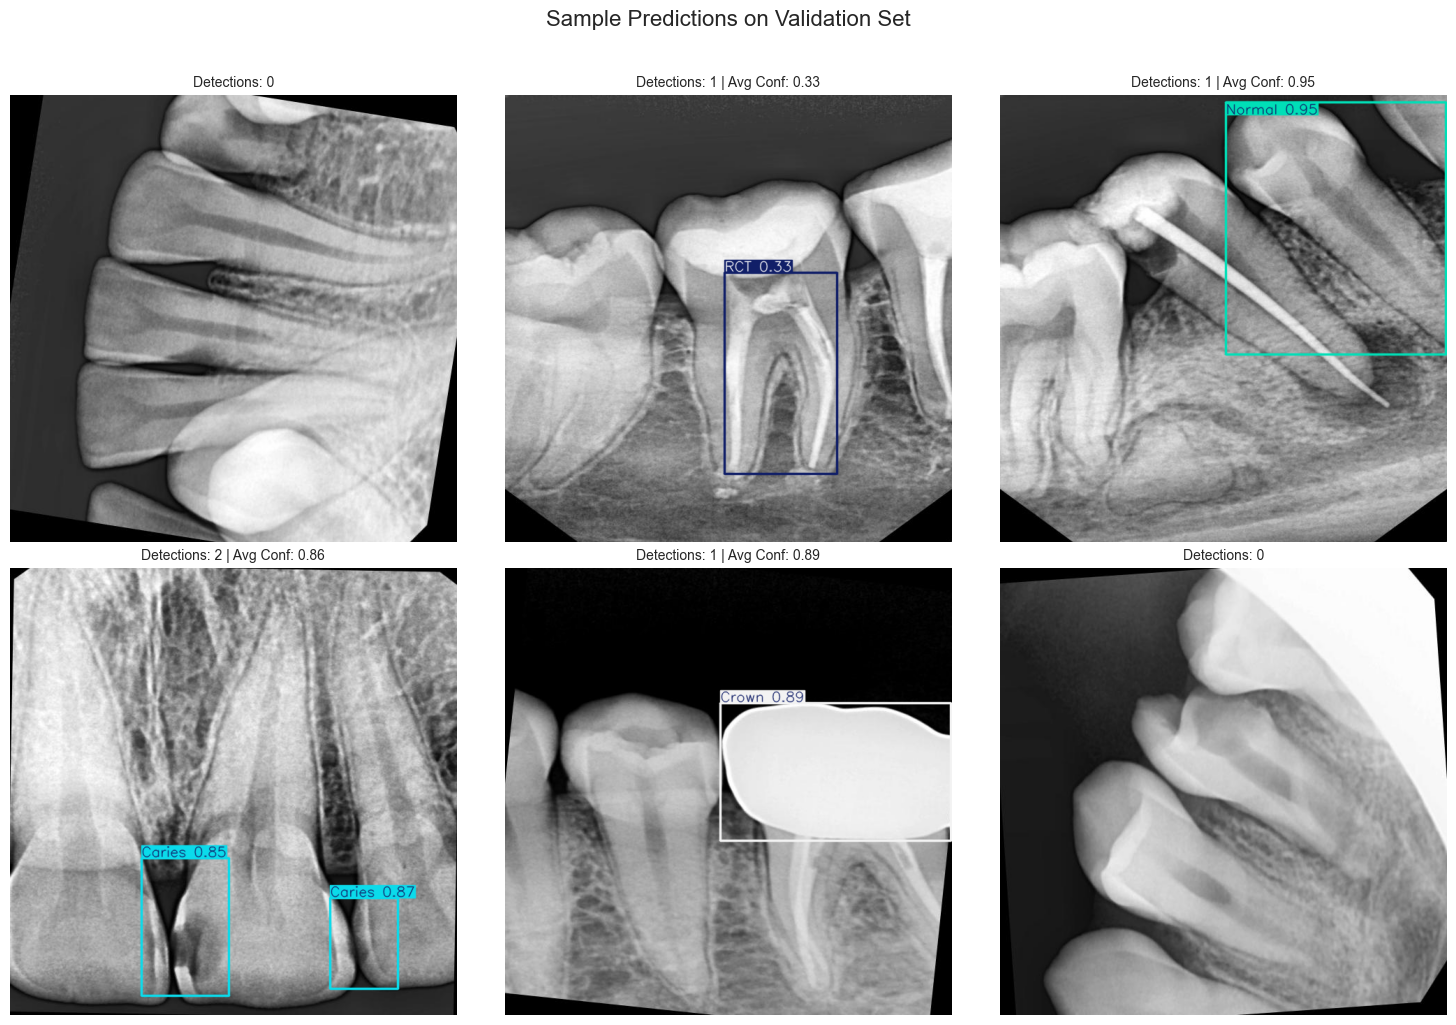

In [26]:
def visualize_predictions(model, val_images_dir, num_samples=9):
    """Display model predictions on random validation images"""
    val_images = list(Path(val_images_dir).glob('*.jpg')) + list(Path(val_images_dir).glob('*.png'))
    if len(val_images) > num_samples:
        val_images = random.sample(val_images, num_samples)
    
    n_cols = 3
    n_rows = (num_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    for idx, img_path in enumerate(val_images):
        # Run inference
        results = model(img_path)
        
        # Get annotated image
        annotated_img = results[0].plot()
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        
        # Display
        axes[idx].imshow(annotated_img_rgb)
        axes[idx].axis('off')
        
        # Add title with detection info
        boxes = results[0].boxes
        if boxes is not None:
            num_detections = len(boxes)
            confidences = boxes.conf.cpu().numpy()
            if len(confidences) > 0:
                avg_conf = np.mean(confidences)
                title = f"Detections: {num_detections} | Avg Conf: {avg_conf:.2f}"
            else:
                title = f"Detections: {num_detections}"
        else:
            title = "No detections"
        axes[idx].set_title(title, fontsize=10)
    
    # Hide unused subplots
    for idx in range(len(val_images), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle("Sample Predictions on Validation Set", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('/kaggle/working/sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize predictions
val_images_dir = yolo_dataset_dir / 'val' / 'images'
visualize_predictions(model, val_images_dir, num_samples=6)

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]


image 1/1 /kaggle/working/yolo_dataset/val/images/-532-_jpg.rf.ad6c3f4ba0df98eeb08c5c38c88f4225.jpg: 640x640 1 Normal, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/OIP-8-_jpg.rf.675e9c0f6b5e96fc4acf152e66922358.jpg: 640x640 1 Crown, 7.2ms
Speed: 1.4ms preprocess, 7.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-432-_jpg.rf.0fe8bcdfcee7b492b38b3548dd925599.jpg: 640x640 1 Badly Decayed, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-268-_jpg.rf.e69f12c7e4e740002006692235faab3a.jpg: 640x640 1 Restoration, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-350-_jpg.rf.5ee39529153db4d44648972f1f9557da.jpg

Evaluating:   7%|▋         | 7/100 [00:00<00:01, 68.33it/s]


image 1/1 /kaggle/working/yolo_dataset/val/images/35_jpeg.rf.28eaf9ed773dcdf93b36785f73cbb1b5.jpg: 640x640 1 Crown, 2 Normals, 7.1ms
Speed: 1.3ms preprocess, 7.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/Primary-Endo-with-Secondary-Perio-98-_JPG.rf.5c83c415031e8bc0b93282d56f806cc2.jpg: 640x640 4 Badly Decayeds, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-373-_jpg.rf.5ec0a05d154416901a812879e76e1465.jpg: 640x640 1 Badly Decayed, 1 Caries, 1 Restoration, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/13_jpg.rf.4cf20f8aa29f8e988694244d9b8b3917.jpg: 640x640 2 Normals, 7.1ms
Speed: 1.3ms preprocess, 7.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_da

Evaluating:  14%|█▍        | 14/100 [00:00<00:01, 68.14it/s]

...

Evaluating:  89%|████████▉ | 89/100 [00:01<00:00, 79.27it/s]


image 1/1 /kaggle/working/yolo_dataset/val/images/-183-_jpg.rf.ec6ff95bec6ff50567e38c739ccdcf86.jpg: 640x640 1 RCT, 4.9ms
Speed: 1.3ms preprocess, 4.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/Primary-Perio-with-Secondary-Endo-2-_JPG.rf.01a6b93ac437d9902ef8c9f788784f82.jpg: 640x640 1 Badly Decayed, 1 Crown, 5.1ms
Speed: 1.3ms preprocess, 5.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-134-_jpg.rf.fb6f5dc94250a925daccbf518e354594.jpg: 640x640 1 RCT, 5.2ms
Speed: 1.3ms preprocess, 5.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-39-_jpg.rf.f3827962bb933915c0fddca53d2f4cbb.jpg: 640x640 1 Restoration, 5.0ms
Speed: 1.3ms preprocess, 5.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/44_jpeg.rf.c38fd

Evaluating:  98%|█████████▊| 98/100 [00:01<00:00, 79.74it/s]


image 1/1 /kaggle/working/yolo_dataset/val/images/-25-_jpg.rf.0f2e4270be742fe53a85bde919a1ef39.jpg: 640x640 3 Normals, 5.2ms
Speed: 1.4ms preprocess, 5.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/yolo_dataset/val/images/-441-_jpg.rf.bc309c0049ef32324961fce5a24cdd70.jpg: 640x640 (no detections), 5.1ms
Speed: 1.3ms preprocess, 5.1ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


Evaluating: 100%|██████████| 100/100 [00:01<00:00, 75.71it/s]


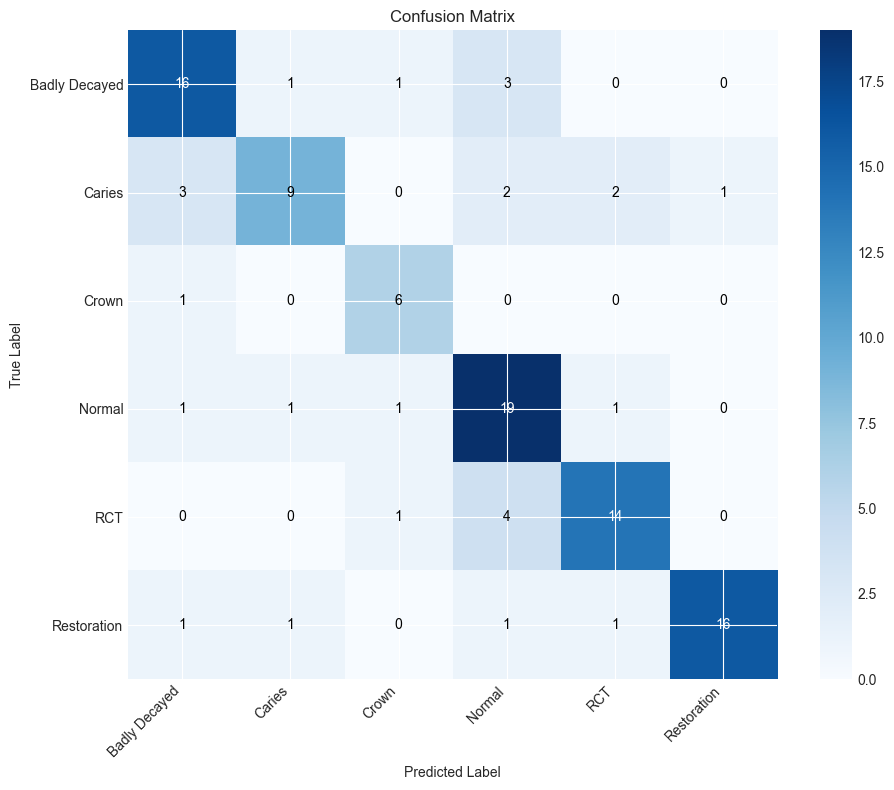


📋 Classification Report:
               precision    recall  f1-score   support

Badly Decayed       0.73      0.76      0.74        21
       Caries       0.75      0.53      0.62        17
        Crown       0.67      0.86      0.75         7
       Normal       0.66      0.83      0.73        23
          RCT       0.78      0.74      0.76        19
  Restoration       0.94      0.80      0.86        20

     accuracy                           0.75       107
    macro avg       0.75      0.75      0.74       107
 weighted avg       0.76      0.75      0.75       107



In [27]:
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def evaluate_predictions(model, val_dir, class_names):
    """Detailed evaluation with confusion matrix (fixed length issue)"""
    
    all_preds = []
    all_labels = []
    
    val_images = list(Path(val_dir).glob('*.jpg')) + list(Path(val_dir).glob('*.png'))
    
    for img_path in tqdm(val_images[:100], desc="Evaluating"):  # Limit for speed
        
        # Get ground truth
        label_path = Path(str(img_path).replace('images', 'labels')
                                         .replace('.jpg', '.txt')
                                         .replace('.png', '.txt'))
        
        if label_path.exists():
            with open(label_path, 'r') as f:
                true_labels = [int(line.split()[0]) for line in f.readlines()]
            
            # Get predictions
            results = model(img_path)
            
            if results[0].boxes is not None and len(results[0].boxes) > 0:
                pred_labels = results[0].boxes.cls.cpu().numpy().astype(int).tolist()
            else:
                pred_labels = []
            
            # 🔥 FIX: make lengths equal
            min_len = min(len(true_labels), len(pred_labels))
            
            if min_len > 0:
                all_labels.extend(true_labels[:min_len])
                all_preds.extend(pred_labels[:min_len])
    
    if len(all_preds) > 0 and len(all_labels) > 0:
        
        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
        
        fig, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.figure.colorbar(im, ax=ax)
        
        ax.set(
            xticks=np.arange(len(class_names)),
            yticks=np.arange(len(class_names)),
            xticklabels=class_names,
            yticklabels=class_names,
            xlabel='Predicted Label',
            ylabel='True Label'
        )
        
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        
        # Numbers inside cells
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j],
                        ha="center", va="center",
                        color="white" if cm[i, j] > cm.max()/2 else "black")
        
        ax.set_title('Confusion Matrix')
        plt.tight_layout()
        plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
        plt.show()
        
        # Classification Report
        print("\n📋 Classification Report:")
        print(classification_report(all_labels, all_preds,
                                    target_names=class_names,
                                    zero_division=0))
    else:
        print("❌ No valid predictions or labels found!")

# Call function
evaluate_predictions(model, val_images_dir, all_classes)

In [28]:
final_model_dir = Path('/kaggle/working/final_model')
final_model_dir.mkdir(exist_ok=True)

In [29]:
final_pt_path = final_model_dir / 'dental_periapical_model.pt'
shutil.copy(best_model_path, final_pt_path)
print(f"✅ PyTorch model saved to {final_pt_path}")

✅ PyTorch model saved to /kaggle/working/final_model/dental_periapical_model.pt


In [30]:
torchscript_path = final_model_dir / 'dental_periapical_model.torchscript'
model.export(format='torchscript', imgsz=640)
shutil.move('/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.torchscript', torchscript_path)
print(f"✅ TorchScript model saved to {torchscript_path}")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 1.6s, saved as '/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.torchscript' (11.9 MB)

Export complete (1.9s)
Results saved to /kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.torchscript imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.torchscript imgsz=6

In [31]:
onnx_path = final_model_dir / 'dental_periapical_model.onnx'
model.export(format='onnx', imgsz=640)
shutil.move('/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.onnx', onnx_path)
print(f"✅ ONNX model saved to {onnx_path}")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 242ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 2.26s
Installed 2 packages in 12ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 2.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 4.2s, saved as '/kaggle/working/runs/detect/dental_model/yolov8n_periapical/weights/best.onnx' (11.7 MB)

Export complete (4.4s)
Results saved to /kaggle/working/runs/de

In [32]:
import json
class_mapping = {
    'class_to_id': class_to_id,
    'id_to_class': id_to_class,
    'class_names': all_classes,
    'num_classes': len(all_classes)
}
with open(final_model_dir / 'class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)

print(f"\n✅ All models saved to {final_model_dir}")


✅ All models saved to /kaggle/working/final_model


In [33]:
def predict_dental_xray(image_path, model_path=None, conf_threshold=0.5):
    """
    Run inference on a dental periapical X-ray image
    
    Args:
        image_path: Path to input image
        model_path: Path to trained model (optional)
        conf_threshold: Confidence threshold for detections
    
    Returns:
        results: YOLO results object
    """
    if model_path is None:
        model_path = final_pt_path
    
    # Load model
    inference_model = YOLO(model_path)
    
    # Run inference
    results = inference_model(image_path, conf=conf_threshold)
    
    # Display results
    annotated_img = results[0].plot()
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f'Dental X-ray Analysis - Confidence ≥ {conf_threshold}')
    plt.show()

In [34]:
from pathlib import Path
from tqdm import tqdm

def print_predictions(model, val_dir, class_names):
    
    val_images = list(Path(val_dir).glob('*.jpg')) + list(Path(val_dir).glob('*.png'))
    
    for img_path in tqdm(val_images[:10], desc="Predictions"):  # عدد قليل للتجربة
        
        results = model(img_path)
        
        print(f"\n📷 Image: {img_path.name}")
        
        if results[0].boxes is not None and len(results[0].boxes) > 0:
            
            boxes = results[0].boxes
            
            pred_classes = boxes.cls.cpu().numpy().astype(int)
            confidences = boxes.conf.cpu().numpy()
            
            for cls, conf in zip(pred_classes, confidences):
                print(f"➡️ Class: {class_names[cls]} | Confidence: {conf:.2f}")
        
        else:
            print("❌ No detections")

In [35]:
print_predictions(model, val_images_dir, all_classes)

Predictions:   0%|          | 0/10 [00:00<?, ?it/s]


image 1/1 /kaggle/working/yolo_dataset/val/images/-532-_jpg.rf.ad6c3f4ba0df98eeb08c5c38c88f4225.jpg: 640x640 1 Normal, 7.3ms
Speed: 1.7ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

📷 Image: -532-_jpg.rf.ad6c3f4ba0df98eeb08c5c38c88f4225.jpg
➡️ Class: Normal | Confidence: 0.38

image 1/1 /kaggle/working/yolo_dataset/val/images/OIP-8-_jpg.rf.675e9c0f6b5e96fc4acf152e66922358.jpg: 640x640 1 Crown, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

📷 Image: OIP-8-_jpg.rf.675e9c0f6b5e96fc4acf152e66922358.jpg
➡️ Class: Crown | Confidence: 0.94

image 1/1 /kaggle/working/yolo_dataset/val/images/-432-_jpg.rf.0fe8bcdfcee7b492b38b3548dd925599.jpg: 640x640 1 Badly Decayed, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

📷 Image: -432-_jpg.rf.0fe8bcdfcee7b492b38b3548dd925599.jpg
➡️ Class: Badly Decayed | Confidence: 0.91

image 1/1 /kaggle/working/yolo_

Predictions:  70%|███████   | 7/10 [00:00<00:00, 66.43it/s]


📷 Image: -455-_jpg.rf.602d1a98b91b867eaa6ebbc0aaa45cc1.jpg
➡️ Class: Normal | Confidence: 0.63
➡️ Class: Normal | Confidence: 0.57

image 1/1 /kaggle/working/yolo_dataset/val/images/35_jpeg.rf.28eaf9ed773dcdf93b36785f73cbb1b5.jpg: 640x640 1 Crown, 2 Normals, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

📷 Image: 35_jpeg.rf.28eaf9ed773dcdf93b36785f73cbb1b5.jpg
➡️ Class: Crown | Confidence: 0.85
➡️ Class: Normal | Confidence: 0.56
➡️ Class: Normal | Confidence: 0.46

image 1/1 /kaggle/working/yolo_dataset/val/images/Primary-Endo-with-Secondary-Perio-98-_JPG.rf.5c83c415031e8bc0b93282d56f806cc2.jpg: 640x640 4 Badly Decayeds, 7.1ms
Speed: 1.3ms preprocess, 7.1ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

📷 Image: Primary-Endo-with-Secondary-Perio-98-_JPG.rf.5c83c415031e8bc0b93282d56f806cc2.jpg
➡️ Class: Badly Decayed | Confidence: 0.73
➡️ Class: Badly Decayed | Confidence: 0.67
➡️ Class: Badly Decayed | Confide

Predictions: 100%|██████████| 10/10 [00:00<00:00, 66.50it/s]


📷 Image: -373-_jpg.rf.5ec0a05d154416901a812879e76e1465.jpg
➡️ Class: Badly Decayed | Confidence: 0.89
➡️ Class: Restoration | Confidence: 0.35
➡️ Class: Caries | Confidence: 0.26
